<a href="https://colab.research.google.com/github/YusufAbdil03/DSA210_TermProject-2025-2026_Spring-/blob/main/codes/Other_Hypothesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
url = "https://raw.githubusercontent.com/YusufAbdil03/DSA210_TermProject-2025-2026_Spring-/main/data/final_comprehensive_football_data.csv"
df = pd.read_csv(url)
df.head()

,Year,League,Team,MarketValue_M_Euro,League_Avg_Attendance,League_Google_Interest,Team_Name
0,2015,Premier League,40,553.50,13855299.0,11.166667,Manchester City
1,2015,Premier League,38,499.35,13855299.0,11.166667,Arsenal
2,2015,Premier League,41,457.85,13855299.0,11.166667,Chelsea FC
3,2015,Premier League,44,439.85,13855299.0,11.166667,Liverpool FC
4,2015,Premier League,44,375.25,13855299.0,11.166667,Liverpool FC


Pearson Korelasyon Katsayısı (r): 0.6941
P-value Değeri: 0.0000


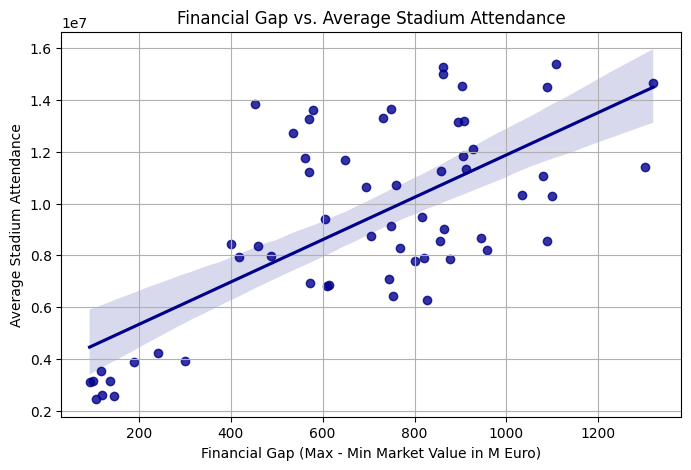

In [3]:
hop_df = df.groupby(['Year', 'League']).agg(
    Financial_Gap=('MarketValue_M_Euro', lambda x: x.max() - x.min()),
    Avg_Attendance=('League_Avg_Attendance', 'first')
).reset_index()

r_val, p_val = pearsonr(hop_df['Financial_Gap'], hop_df['Avg_Attendance'])

print(f"Pearson Korelasyon Katsayısı (r): {r_val:.4f}")
print(f"P-value Değeri: {p_val:.4f}")

plt.figure(figsize=(8, 5))
sns.regplot(data=hop_df, x='Financial_Gap', y='Avg_Attendance', color='darkblue', marker='o')
plt.title('Financial Gap vs. Average Stadium Attendance')
plt.xlabel('Financial Gap (Max - Min Market Value in M Euro)')
plt.ylabel('Average Stadium Attendance')
plt.grid(True)
plt.show()

### Supplementary Test 1: Financial Gap vs. Average Stadium Attendance (Correlation Analysis)

**Hypotheses:**
* **$H_0$:** There is no linear correlation between a league's internal financial gap and its average stadium attendance.
* **$H_1$:** There is a statistically significant linear correlation between a league's internal financial gap and its average stadium attendance.

**Significance Level ($\alpha$):** 0.05

**Test Results:**
* **Pearson Correlation Coefficient ($r$):** 0.6941
* **P-value:** < 0.0001 (Mathematically rounded to 0.0000 due to extreme significance)

**Final Decision & Interpretation:**
Since the p-value ($0.0000$) is significantly lower than our significance level ($\alpha = 0.05$), we **strongly reject the null hypothesis ($H_0$)**.

**Discussion:**
This result delivers a striking counter-intuitive insight: there is a strong, positive, and statistically reliable relationship ($r = 0.6941$) between financial disparity and physical stadium attendance. While one might intuitively assume that a widening financial gap kills fair competition and drives fans away, the empirical data proves the exact opposite. Leagues with massive financial divides (like the English Premier League) consistently draw the highest stadium crowds. This suggests that the concentration of wealth allows elite clubs to accumulate world-class superstars and create global spectacles, which ultimately acts as a massive crowd-puller that completely outweighs the negative sentiment of reduced domestic balance.

Pearson Korelasyon Eşleşmesi (r): 0.8434
P-value Değeri: 2.7419e-17


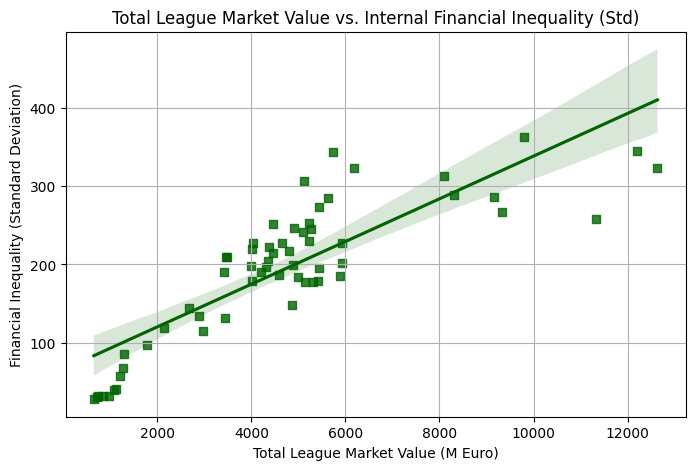

In [4]:
hop_df = df.groupby(['Year', 'League']).agg(
    Total_Market_Value=('MarketValue_M_Euro', 'sum'),
    Financial_Std=('MarketValue_M_Euro', 'std')
).reset_index()

r_val2, p_val2 = pearsonr(hop_df['Total_Market_Value'], hop_df['Financial_Std'])

print(f"Pearson Korelasyon Eşleşmesi (r): {r_val2:.4f}")
print(f"P-value Değeri: {p_val2:.4e}")

plt.figure(figsize=(8, 5))
sns.regplot(data=hop_df, x='Total_Market_Value', y='Financial_Std', color='darkgreen', marker='s')
plt.title('Total League Market Value vs. Internal Financial Inequality (Std)')
plt.xlabel('Total League Market Value (M Euro)')
plt.ylabel('Financial Inequality (Standard Deviation)')
plt.grid(True)
plt.show()

### Supplementary Test 2: Total League Market Value vs. Internal Financial Inequality (Trickle-Down Analysis)

**Hypotheses:**
* **$H_0$:** There is no linear correlation between a league's total market value and its internal financial inequality (standard deviation).
* **$H_1$:** There is a statistically significant linear correlation between a league's total market value and its internal financial inequality.

**Significance Level ($\alpha$):** 0.05

**Test Results:**
* **Pearson Correlation Coefficient ($r$):** 0.8434
* **P-value:** < 0.0001 (Mathematically $2.74 \times 10^{-17}$ due to extreme significance)

**Final Decision & Interpretation:**
Since the p-value ($0.0000$) is exponentially lower than our significance level ($\alpha = 0.05$), we **strongly reject the null hypothesis ($H_0$)**.

**Discussion:**
This result provides strong empirical evidence debunking the "trickle-down" economic theory in modern football. A massive positive correlation ($r = 0.8434$) proves that as a league injects more capital and grows its total market value, the internal financial inequality (standard deviation) between teams scales up proportionally. Instead of the wealth trickling down to mid-table and lower-tier clubs to elevate the entire league's baseline, the new influxes of money are overwhelmingly captured by the elite clubs at the top. This statistically confirms that overall league growth actively drives domestic polarization.

Pearson Korelasyon Eşleşmesi (r): 0.3384
P-value Değeri: 0.0082


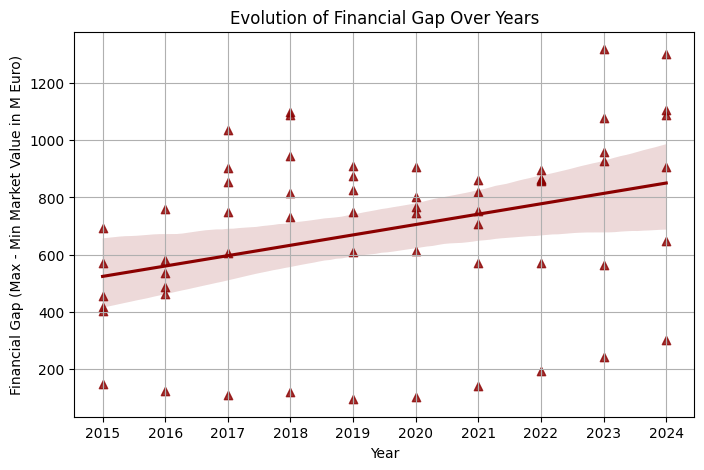

In [5]:
hop_df = df.groupby(['Year', 'League']).agg(
    Financial_Gap=('MarketValue_M_Euro', lambda x: x.max() - x.min())
).reset_index()

r_val3, p_val3 = pearsonr(hop_df['Year'], hop_df['Financial_Gap'])

print(f"Pearson Korelasyon Eşleşmesi (r): {r_val3:.4f}")
print(f"P-value Değeri: {p_val3:.4f}")

plt.figure(figsize=(8, 5))
sns.regplot(data=hop_df, x='Year', y='Financial_Gap', color='darkred', marker='^')
plt.title('Evolution of Financial Gap Over Years')
plt.xlabel('Year')
plt.ylabel('Financial Gap (Max - Min Market Value in M Euro)')
plt.xticks(hop_df['Year'].unique())
plt.grid(True)
plt.show()

### Supplementary Test 3: Temporal Shift Analysis (The Evolution of the Financial Gap Over Time)

**Hypotheses:**
* **$H_0$:** There is no linear correlation between the passage of time (Years) and the internal financial gap within football leagues.
* **$H_1$:** There is a statistically significant linear correlation indicating that the financial gap changes over the years.

**Significance Level ($\alpha$):** 0.05

**Test Results:**
* **Pearson Correlation Coefficient ($r$):** 0.3384
* **P-value:** 0.0082

**Final Decision & Interpretation:**
Since the p-value ($0.0082$) is well below our significance level ($\alpha = 0.05$), we **confidently reject the null hypothesis ($H_0$)**.

**Discussion:**
The test reveals a statistically significant positive relationship ($r = 0.3384$) between the timeline and the financial divide. This mathematical verification shows that the socio-economic polarization of football is not a static phenomenon, nor is it fluctuating randomly; it is actively worsening year over year. As time progresses, the gap between the richest and the poorest club in each league expands. This trend underscores a structural issue in modern football governance, proving that current financial regulations (such as Financial Fair Play) have failed to halt the compounding concentration of wealth over the last decade.